# Inspeção Visual de Peças Metálicas

Mini-projeto de Machine Learning e Visão Computacional desenvolvido para o programa SCTEC.

## 1. Configuração do ambiente

Nesta etapa, verificamos o ambiente Python, importamos as bibliotecas utilizadas na análise exploratória e definimos os caminhos para acessar o dataset.

In [2]:
import sys

print(f"Python em uso: {sys.executable}")
print(f"Versão do Python: {sys.version}")

Python em uso: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\.venv\Scripts\python.exe
Versão do Python: 3.13.12 (main, Feb 12 2026, 00:38:53) [MSC v.1944 64 bit (AMD64)]


In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Identifica a pasta em que o notebook está sendo executado.
RAIZ_PROJETO = Path.cwd()

# Caso a execução comece em "notebooks", retorna à raiz do projeto.
if RAIZ_PROJETO.name == "notebooks":
    RAIZ_PROJETO = RAIZ_PROJETO.parent

# Define os caminhos do dataset e de suas duas classes.
PASTA_DATASET = RAIZ_PROJETO / "data" / "raw" / "casting_512x512"
PASTA_DEFEITUOSAS = PASTA_DATASET / "def_front"
PASTA_OK = PASTA_DATASET / "ok_front"

# Confere se as pastas foram localizadas.
print(f"Raiz do projeto: {RAIZ_PROJETO}")
print(f"Dataset encontrado: {PASTA_DATASET.exists()}")
print(f"Pasta de peças defeituosas: {PASTA_DEFEITUOSAS.exists()}")
print(f"Pasta de peças OK: {PASTA_OK.exists()}")

Raiz do projeto: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn
Dataset encontrado: True
Pasta de peças defeituosas: True
Pasta de peças OK: True


## 2. Conhecendo o dataset

O dataset está dividido em duas classes:

- `def_front`: peças com defeitos;
- `ok_front`: peças sem defeitos.

A seguir, verificamos a quantidade de imagens e a proporção de cada classe.

In [5]:
# Localiza e organiza os arquivos JPEG de cada classe.
imagens_defeituosas = sorted(PASTA_DEFEITUOSAS.glob("*.jpeg"))
imagens_ok = sorted(PASTA_OK.glob("*.jpeg"))

quantidade_defeituosas = len(imagens_defeituosas)
quantidade_ok = len(imagens_ok)
total_imagens = quantidade_defeituosas + quantidade_ok

# Calcula a participação percentual de cada classe.
percentual_defeituosas = quantidade_defeituosas / total_imagens * 100
percentual_ok = quantidade_ok / total_imagens * 100

print(
    f"Peças defeituosas: {quantidade_defeituosas} "
    f"({percentual_defeituosas:.1f}%)"
)
print(
    f"Peças OK: {quantidade_ok} "
    f"({percentual_ok:.1f}%)"
)
print(f"Total de imagens: {total_imagens}")

Peças defeituosas: 781 (60.1%)
Peças OK: 519 (39.9%)
Total de imagens: 1300


### Análise da distribuição

O dataset contém 1.300 imagens, sendo 781 peças defeituosas (60,1%) e 519 peças sem defeito (39,9%).

Existe um desbalanceamento moderado entre as classes. Portanto, além da acurácia, será importante observar métricas como precisão, recall, F1-score e matriz de confusão durante a avaliação do modelo.

## 3. Validação técnica das imagens

Antes do processamento, verificamos se todas as imagens podem ser carregadas corretamente e se possuem dimensões, número de canais e tipo de dados consistentes.


In [6]:
todas_as_imagens = imagens_defeituosas + imagens_ok

imagens_invalidas = []
dimensoes_encontradas = set()
quantidades_canais = set()
tipos_de_dados = set()

# Percorre todas as imagens para verificar sua integridade e características.
for caminho_imagem in todas_as_imagens:
    imagem = cv2.imread(str(caminho_imagem))

    if imagem is None:
        imagens_invalidas.append(caminho_imagem.name)
        continue

    altura, largura = imagem.shape[:2]
    dimensoes_encontradas.add((largura, altura))

    # Imagens coloridas carregadas pelo OpenCV possuem três canais: B, G e R.
    canais = imagem.shape[2] if imagem.ndim == 3 else 1
    quantidades_canais.add(canais)

    tipos_de_dados.add(str(imagem.dtype))

print(f"Imagens verificadas: {len(todas_as_imagens)}")
print(f"Imagens inválidas: {len(imagens_invalidas)}")
print(f"Dimensões encontradas: {sorted(dimensoes_encontradas)}")
print(f"Quantidade de canais: {sorted(quantidades_canais)}")
print(f"Tipos de dados: {sorted(tipos_de_dados)}")

Imagens verificadas: 1300
Imagens inválidas: 0
Dimensões encontradas: [(512, 512)]
Quantidade de canais: [3]
Tipos de dados: ['uint8']


### Resultado da validação

Todas as 1.300 imagens foram carregadas corretamente, sem arquivos inválidos. As imagens possuem dimensões uniformes de 512 × 512 pixels e três canais de cores.

O tipo `uint8` indica que cada canal utiliza valores inteiros entre 0 e 255. Essa consistência facilita a aplicação dos filtros do OpenCV e o posterior treinamento da CNN.

## 4. Inspeção visual das imagens

Nesta etapa, selecionamos amostras das duas classes para observar diferenças visuais entre peças defeituosas e peças sem defeito.

Como o OpenCV carrega imagens no padrão BGR, realizamos a conversão para RGB antes da exibição com o Matplotlib.

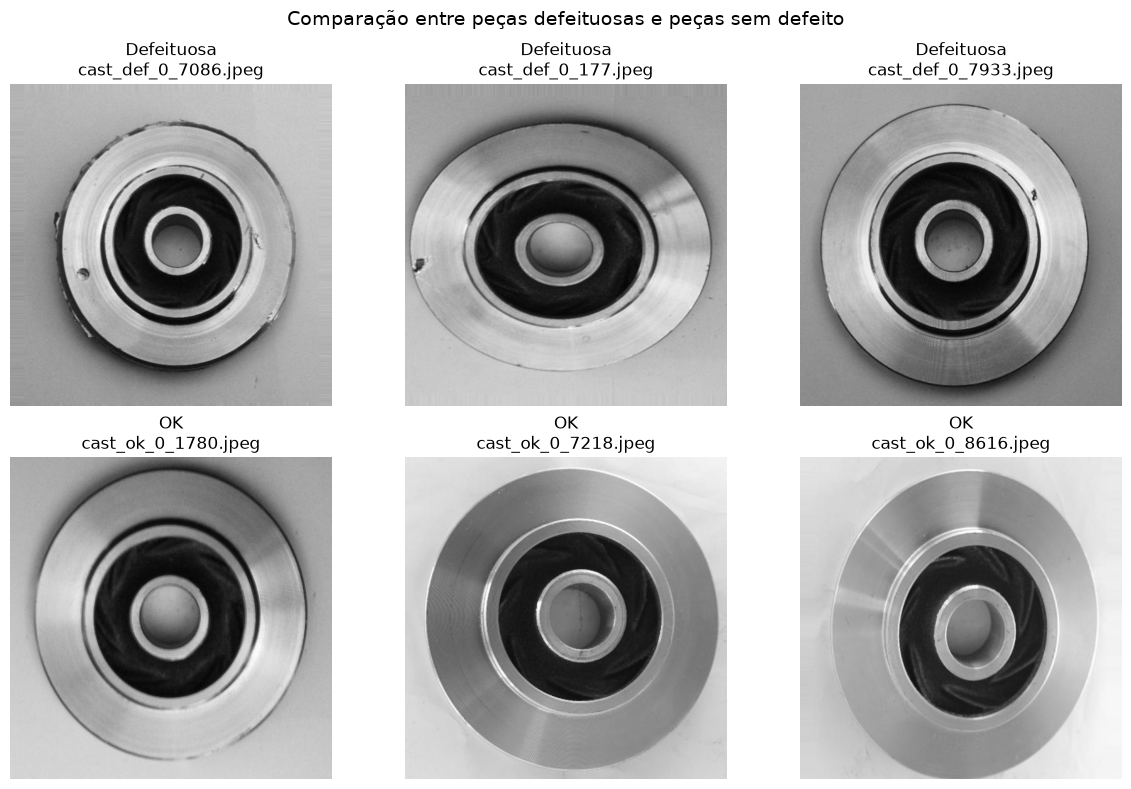

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\comparacao_classes.png


In [7]:
# Utiliza uma semente fixa para repetir a mesma seleção em outras execuções.
gerador = np.random.default_rng(42)

indices_defeituosas = gerador.choice(
    len(imagens_defeituosas),
    size=3,
    replace=False
)

indices_ok = gerador.choice(
    len(imagens_ok),
    size=3,
    replace=False
)

amostras_defeituosas = [
    imagens_defeituosas[indice]
    for indice in indices_defeituosas
]

amostras_ok = [
    imagens_ok[indice]
    for indice in indices_ok
]

figura, eixos = plt.subplots(2, 3, figsize=(12, 8))

# A primeira linha apresenta peças defeituosas.
for coluna, caminho_imagem in enumerate(amostras_defeituosas):
    imagem_bgr = cv2.imread(str(caminho_imagem))
    imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

    eixos[0, coluna].imshow(imagem_rgb)
    eixos[0, coluna].set_title(f"Defeituosa\n{caminho_imagem.name}")
    eixos[0, coluna].axis("off")

# A segunda linha apresenta peças sem defeito.
for coluna, caminho_imagem in enumerate(amostras_ok):
    imagem_bgr = cv2.imread(str(caminho_imagem))
    imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

    eixos[1, coluna].imshow(imagem_rgb)
    eixos[1, coluna].set_title(f"OK\n{caminho_imagem.name}")
    eixos[1, coluna].axis("off")

figura.suptitle(
    "Comparação entre peças defeituosas e peças sem defeito",
    fontsize=14
)

figura.tight_layout()

# Salva a comparação para uso posterior no README e na apresentação.
caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "comparacao_classes.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura salva em: {caminho_saida}")

### Observações da inspeção visual

Nas amostras defeituosas, observam-se pequenas marcas escuras, cavidades e irregularidades localizadas principalmente na superfície metálica externa da peça.

As peças classificadas como OK apresentam superfícies mais uniformes e sem descontinuidades evidentes. Entretanto, existem variações de iluminação, contraste e posicionamento entre as imagens.

Essas características justificam o uso de técnicas como suavização, limiarização e detecção de bordas para destacar os defeitos.

## 5. Pré-processamento com OpenCV

### 5.1 Conversão para escala de cinza

A conversão para escala de cinza reduz a imagem de três canais para apenas um canal de intensidade. Isso simplifica o processamento e permite concentrar a análise nos contrastes, contornos e irregularidades da peça.

In [8]:
# Seleciona uma das peças defeituosas exibidas anteriormente.
caminho_amostra = amostras_defeituosas[0]

# Carrega a imagem no formato BGR utilizado pelo OpenCV.
imagem_bgr = cv2.imread(str(caminho_amostra))

if imagem_bgr is None:
    raise FileNotFoundError(f"Não foi possível carregar: {caminho_amostra}")

# Prepara duas representações da mesma imagem.
imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
imagem_cinza = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

print(f"Formato da imagem original: {imagem_bgr.shape}")
print(f"Formato da imagem em escala de cinza: {imagem_cinza.shape}")

Formato da imagem original: (512, 512, 3)
Formato da imagem em escala de cinza: (512, 512)


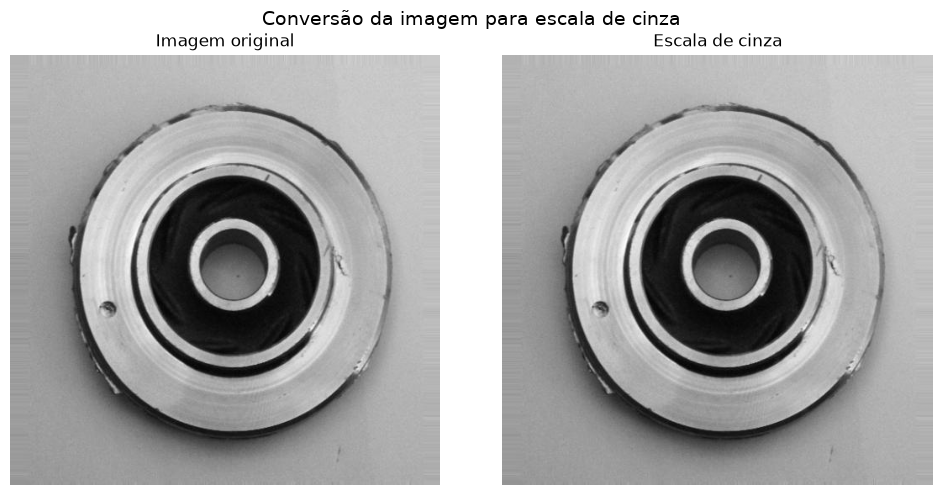

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\conversao_escala_cinza.png


In [9]:
figura, eixos = plt.subplots(1, 2, figsize=(10, 5))

eixos[0].imshow(imagem_rgb)
eixos[0].set_title("Imagem original")
eixos[0].axis("off")

eixos[1].imshow(imagem_cinza, cmap="gray")
eixos[1].set_title("Escala de cinza")
eixos[1].axis("off")

figura.suptitle("Conversão da imagem para escala de cinza", fontsize=14)
figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "conversao_escala_cinza.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### 5.2 Suavização de ruídos

Filtros de suavização reduzem pequenas variações de intensidade e ruídos presentes na imagem. Nesta comparação, aplicamos Gaussian Blur e Median Blur para observar seus efeitos antes da detecção de bordas.

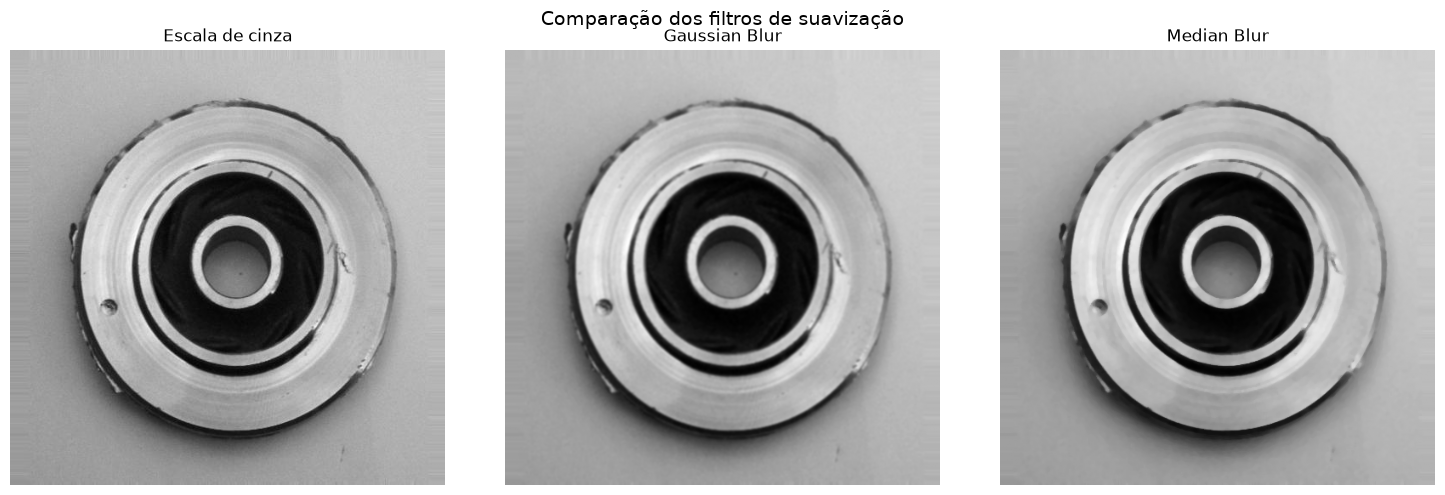

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\comparacao_filtros_suavizacao.png


In [10]:
# O kernel 5 × 5 define a região considerada no cálculo da suavização.
imagem_gaussian = cv2.GaussianBlur(
    imagem_cinza,
    (5, 5),
    0
)

imagem_median = cv2.medianBlur(
    imagem_cinza,
    5
)

figura, eixos = plt.subplots(1, 3, figsize=(15, 5))

imagens = [
    imagem_cinza,
    imagem_gaussian,
    imagem_median
]

titulos = [
    "Escala de cinza",
    "Gaussian Blur",
    "Median Blur"
]

for eixo, imagem, titulo in zip(eixos, imagens, titulos):
    eixo.imshow(imagem, cmap="gray")
    eixo.set_title(titulo)
    eixo.axis("off")

figura.suptitle("Comparação dos filtros de suavização", fontsize=14)
figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "comparacao_filtros_suavizacao.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### Escolha do filtro

Os dois filtros reduziram ruídos e pequenas variações da superfície metálica. O Median Blur apresentou uma suavização mais intensa, enquanto o Gaussian Blur preservou melhor os contornos principais da peça.

Por esse motivo, o Gaussian Blur foi escolhido para continuar o pipeline. Ele oferece um equilíbrio entre redução de ruído e preservação das características necessárias para a detecção de bordas.

## 6. Destaque de características

### 6.1 Limiarização

A limiarização transforma a imagem em uma representação binária, separando pixels claros e escuros. Utilizamos o método de Otsu para calcular automaticamente o valor de corte com base na distribuição das intensidades da imagem.

A limiarização invertida faz com que as regiões mais escuras sejam representadas em branco, facilitando a visualização de cavidades e irregularidades.

In [11]:
# O valor inicial zero permite que o método de Otsu
# determine automaticamente o melhor limiar.
valor_limiar, imagem_limiarizada = cv2.threshold(
    imagem_gaussian,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print(f"Limiar calculado pelo método de Otsu: {valor_limiar:.0f}")

Limiar calculado pelo método de Otsu: 108


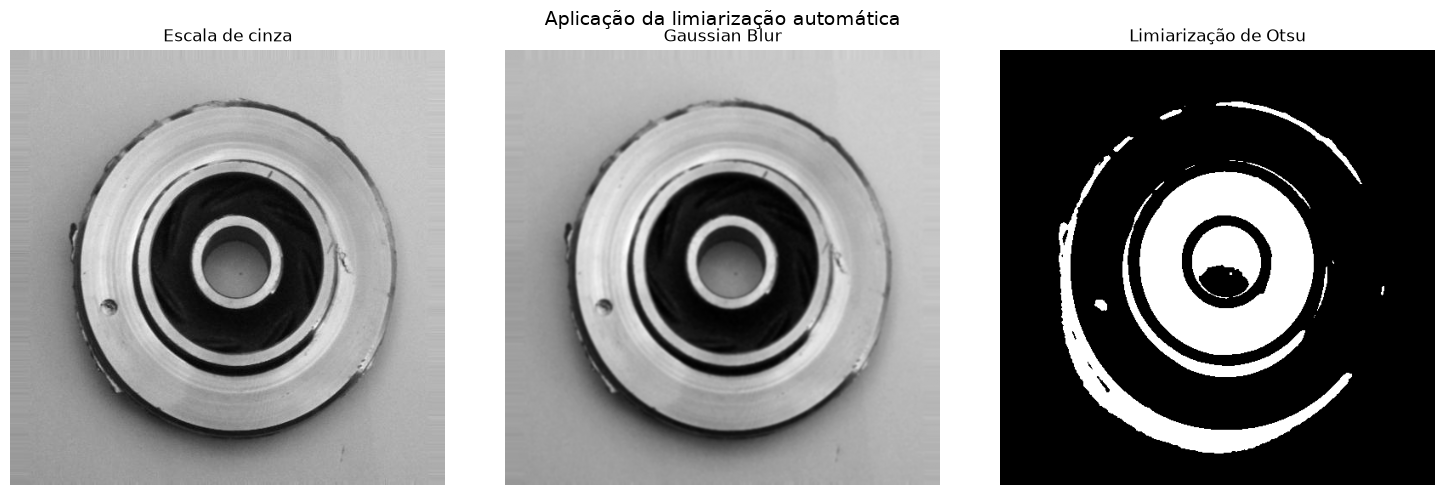

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\limiarizacao_otsu.png


In [12]:
figura, eixos = plt.subplots(1, 3, figsize=(15, 5))

imagens = [
    imagem_cinza,
    imagem_gaussian,
    imagem_limiarizada
]

titulos = [
    "Escala de cinza",
    "Gaussian Blur",
    "Limiarização de Otsu"
]

for eixo, imagem, titulo in zip(eixos, imagens, titulos):
    eixo.imshow(imagem, cmap="gray")
    eixo.set_title(titulo)
    eixo.axis("off")

figura.suptitle("Aplicação da limiarização automática", fontsize=14)
figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "limiarizacao_otsu.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### Resultado da limiarização

O método de Otsu calculou automaticamente o limiar 108. Na imagem binária, as regiões com intensidade abaixo desse valor foram destacadas em branco.

A técnica evidenciou áreas escuras e irregularidades na parte externa da peça, mas também segmentou regiões normais do componente. Assim, a limiarização é útil para separar regiões de interesse, porém deverá ser combinada com detecção de bordas e operações morfológicas.

### 6.2 Detecção de bordas com Canny

O algoritmo Canny identifica mudanças intensas de luminosidade, destacando contornos e descontinuidades na imagem.

São utilizados dois limites: o inferior detecta possíveis bordas e o superior confirma as bordas mais fortes. O Gaussian Blur aplicado anteriormente ajuda a reduzir falsas detecções causadas por ruídos.

In [13]:
limiar_inferior = 50
limiar_superior = 150

# Aplica o Canny sobre a imagem previamente suavizada.
bordas_canny = cv2.Canny(
    imagem_gaussian,
    limiar_inferior,
    limiar_superior
)

# Calcula quantos pixels foram classificados como bordas.
quantidade_pixels_borda = np.count_nonzero(bordas_canny)
percentual_pixels_borda = (
    quantidade_pixels_borda / bordas_canny.size * 100
)

print(f"Limites utilizados: {limiar_inferior} e {limiar_superior}")
print(f"Pixels de borda: {quantidade_pixels_borda}")
print(f"Percentual da imagem: {percentual_pixels_borda:.2f}%")

Limites utilizados: 50 e 150
Pixels de borda: 6404
Percentual da imagem: 2.44%


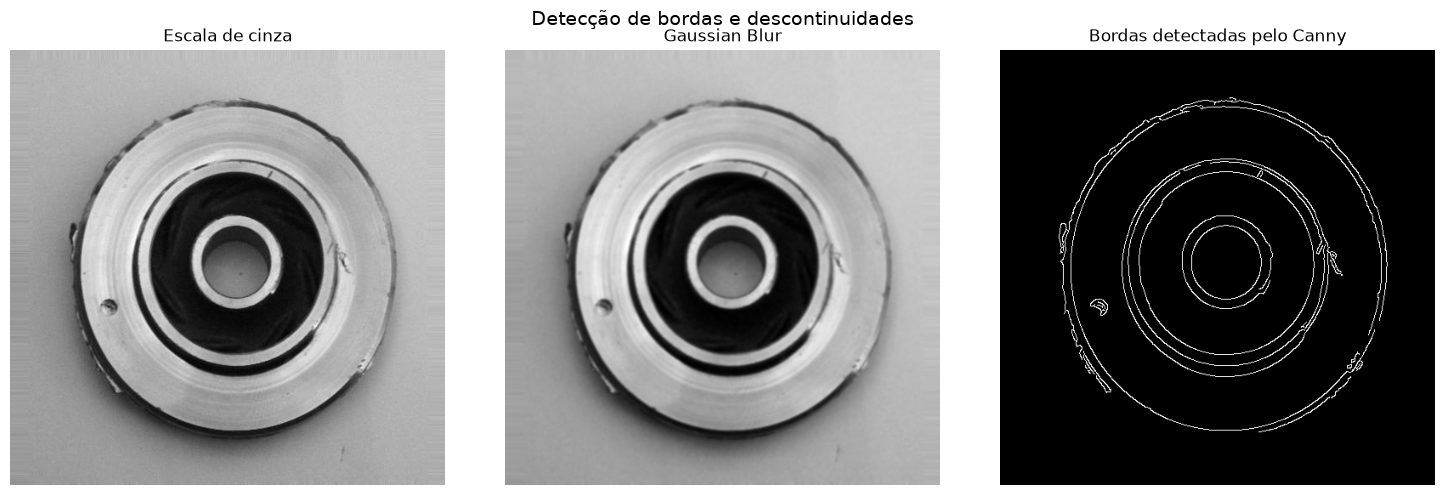

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\deteccao_bordas_canny.png


In [14]:
figura, eixos = plt.subplots(1, 3, figsize=(15, 5))

imagens = [
    imagem_cinza,
    imagem_gaussian,
    bordas_canny
]

titulos = [
    "Escala de cinza",
    "Gaussian Blur",
    "Bordas detectadas pelo Canny"
]

for eixo, imagem, titulo in zip(eixos, imagens, titulos):
    eixo.imshow(imagem, cmap="gray")
    eixo.set_title(titulo)
    eixo.axis("off")

figura.suptitle("Detecção de bordas e descontinuidades", fontsize=14)
figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "deteccao_bordas_canny.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### Resultado da detecção de bordas

O Canny destacou os principais contornos circulares da peça e algumas descontinuidades presentes na superfície. A pequena cavidade localizada no lado esquerdo foi identificada como um contorno fechado.

Os pixels de borda representam 2,44% da imagem, indicando que os limites 50 e 150 produziram uma detecção seletiva, sem excesso de ruído. Entretanto, algumas bordas permanecem finas ou descontínuas, o que será tratado com operações morfológicas.